Загрузка данных из: D:\Education\Arcticle\dtp_project\data\processed\dtp_full_dataset.parquet
Режим таргета: binary_severe. Распределение:
target
0    0.6065
1    0.3935
Name: proportion, dtype: float64
Test size: 33490

--- CatBoost Prediction ---
CatBoost AUC: 0.74348

--- Neural Network Prediction ---


C:\Users\danii\AppData\Local\Temp\ipykernel_25132\4133116200.py:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_model.load_state_dict(torch.load(MODELS_DIR / "best_neu

NeuralNet AUC: 0.73687

--- Blending Results ---
Корреляция предсказаний моделей: 0.9211


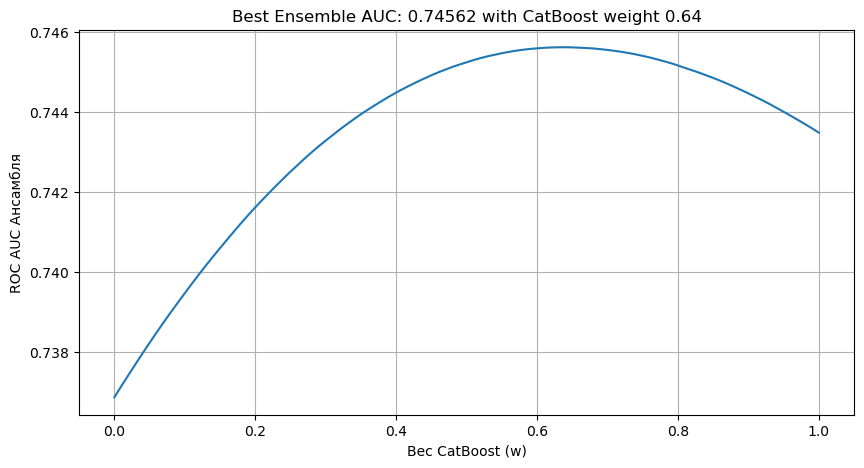


WINNER CONFIGURATION:
CatBoost Weight: 0.64
NN Weight:       0.36
Final AUC:       0.74562
Final F1 Macro:  0.67254


In [1]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score
from catboost import CatBoostClassifier, Pool

# Утилиты
sys.path.append(os.path.abspath('..'))
from notebook_utils import setup_env, load_data_for_modeling

# Настройка
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT, config = setup_env()
MODELS_DIR = PROJECT_ROOT / config['paths']['models']

# ==========================================
# 1. Загрузка данных и восстановление сплита
# ==========================================
# Важно: используем тот же random_state=42, чтобы Test совпадал с прошлыми запусками
df = load_data_for_modeling(config, PROJECT_ROOT, fill_cats=True)

target_col = config['features']['target_col']
cat_cols = config['features']['cat_cols']
num_cols = [c for c in df.columns if c not in cat_cols and c != target_col]

X = df.drop(columns=[target_col])
y = df[target_col]

# Сплит должен быть ИДЕНТИЧЕН тому, на чем учились модели
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test size: {len(X_test)}")

# ==========================================
# 2. Получаем предсказания от CatBoost
# ==========================================
print("\n--- CatBoost Prediction ---")
# CatBoost умеет работать с сырыми данными, просто указываем категории
test_pool = Pool(X_test, cat_features=cat_cols)

# Загружаем модель
cb_model = CatBoostClassifier()
cb_model.load_model(str(MODELS_DIR / f"catboost_{config['experiment']['target_mode']}.cbm"))

# Предсказываем вероятности класса 1
probs_catboost = cb_model.predict_proba(test_pool)[:, 1]
print(f"CatBoost AUC: {roc_auc_score(y_test, probs_catboost):.5f}")

# ==========================================
# 3. Получаем предсказания от Neural Network
# ==========================================
print("\n--- Neural Network Prediction ---")

# (!) Нужно повторить препроцессинг NN точь-в-точь
# 1. Label Encoding (фитим на Train+Test или просто на всем X, как делали в nn ноутбуке)
# В прошлом ноутбуке мы фитили на полном X перед сплитом. Повторяем.
X_nn = X.copy()
label_encoders = {}
cat_dims = []

for col in cat_cols:
    le = LabelEncoder()
    X_nn[col] = le.fit_transform(X_nn[col].astype(str))
    label_encoders[col] = le
    cat_dims.append(len(le.classes_))

# 2. Scaling (фитим на Train, трансформируем Test)
# Нам нужно восстановить X_train_nn и X_test_nn
X_train_nn, X_test_nn, _, _ = train_test_split(
    X_nn, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_nn[num_cols]) # Фитимся
X_test_num = scaler.transform(X_test_nn[num_cols])       # Трансформируем тест

# Подготовка тензоров
x_test_cat_tensor = torch.tensor(X_test_nn[cat_cols].values, dtype=torch.long).to(DEVICE)
x_test_num_tensor = torch.tensor(X_test_num, dtype=torch.float32).to(DEVICE)

# 3. Архитектура модели (должна совпадать с saved state dict)
class TabularModel(nn.Module):
    def __init__(self, cat_dims, num_features, hidden_dims=[512, 256, 128], dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(dim, min(50, (dim + 1) // 2)) for dim in cat_dims
        ])
        total_emb_dim = sum([min(50, (dim + 1) // 2) for dim in cat_dims])
        input_dim = total_emb_dim + num_features
        
        layers = []
        curr_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.BatchNorm1d(curr_dim))
            layers.append(nn.Linear(curr_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = h_dim
        self.mlp = nn.Sequential(*layers)
        self.output = nn.Linear(curr_dim, 1)

    def forward(self, x_cat, x_num):
        emb = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(emb + [x_num], dim=1)
        return self.output(self.mlp(x))

# Загружаем веса
nn_model = TabularModel(cat_dims, len(num_cols)).to(DEVICE)
nn_model.load_state_dict(torch.load(MODELS_DIR / "best_neural_net.pth", map_location=DEVICE))
nn_model.eval()

# Предсказываем
with torch.no_grad():
    logits = nn_model(x_test_cat_tensor, x_test_num_tensor)
    probs_nn = torch.sigmoid(logits).cpu().numpy().flatten()

print(f"NeuralNet AUC: {roc_auc_score(y_test, probs_nn):.5f}")

# ==========================================
# 4. Блендинг (Ансамбль)
# ==========================================
print("\n--- Blending Results ---")

# Проверяем корреляцию предсказаний.
# Если она < 0.9, то буст будет сильным. Если > 0.95, то слабым.
corr = np.corrcoef(probs_catboost, probs_nn)[0, 1]
print(f"Корреляция предсказаний моделей: {corr:.4f}")

# Перебор весов для поиска лучшей комбинации
best_auc = 0
best_w = 0

weights = np.linspace(0, 1, 101) # от 0.00 до 1.00 с шагом 0.01
auc_scores = []

for w in weights:
    # Формула ансамбля: w * CatBoost + (1-w) * NN
    probs_ensemble = w * probs_catboost + (1 - w) * probs_nn
    score = roc_auc_score(y_test, probs_ensemble)
    auc_scores.append(score)
    
    if score > best_auc:
        best_auc = score
        best_w = w

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(weights, auc_scores)
plt.xlabel("Вес CatBoost (w)")
plt.ylabel("ROC AUC Ансамбля")
plt.title(f"Best Ensemble AUC: {best_auc:.5f} with CatBoost weight {best_w:.2f}")
plt.grid(True)
plt.show()

print(f"\nWINNER CONFIGURATION:")
print(f"CatBoost Weight: {best_w:.2f}")
print(f"NN Weight:       {1 - best_w:.2f}")
print(f"Final AUC:       {best_auc:.5f}")

# Считаем F1 для лучшего ансамбля
final_probs = best_w * probs_catboost + (1 - best_w) * probs_nn
final_preds = (final_probs >= 0.5).astype(int)
print(f"Final F1 Macro:  {f1_score(y_test, final_preds, average='macro'):.5f}")